# FPL Points Predictor: Machine Learning Model Deep Dive & Interpretability

## Executive Summary
This notebook presents an in-depth analysis of the tree-based Machine Learning models (**XGBoost** and **Random Forest**) deployed in our Fantasy Premier League (FPL) backtesting pipeline. 

Having established that XGBoost consistently outperforms our baseline Poisson probabilistic model from Gameweek 4/5 onwards, our objectives here are:
1. **Feature Attribution**: Determine which feature sets (3-GW vs. 5-GW rolling metrics, positional indicators, home/away status) drive model decision-making.
2. **SHAP Interpretability**: Quantify marginal feature impacts on expected points (xP) using TreeSHAP.
3. **Residual Diagnostics**: Analyze error distributions and profile extreme failure modes.
4. **Positional Breakdown**: Segment model error across GKP, DEF, MID, and FWD assets.

## 1. Environment Setup & Data Preparation

We load the preprocessed Feature Mart generated from Vaastava's historical dataset (`merged_gw.csv`), configure categorical one-hot encodings for player positions, and split the data into feature matrices (X) and ground-truth targets (y = total_points).

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Append root directory to sys.path for internal imports
sys.path.append("..")
from src.loader import load_and_prepare_data
from src.predict_xp import calculate_xp_engine, predict_xmin

# Formatting defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

# Load dataset
DATA_PATH = Path("../data/merged_gw.csv")
df = load_and_prepare_data(DATA_PATH)

# Enforce standard position mappings & One-Hot Encoding
for pos in ["GK", "DEF", "MID", "FWD"]:
    df[f"pos_{pos}"] = (df["position"] == pos).astype(int)

# Define explicit feature columns
FEATURE_COLS = [
    "rolling_min_3",
    "rolling_starts_3",
    "rolling_xG_90_3",
    "rolling_xA_90_3",
    "rolling_xGC_90_3",
    "rolling_pts_3",
    "rolling_defcon_90_3",
    "rolling_saves_90_3",
    "rolling_min_5",
    "rolling_starts_5",
    "rolling_xG_90_5",
    "rolling_xA_90_5",
    "rolling_xGC_90_5",
    "rolling_pts_5",
    "rolling_defcon_90_5",
    "rolling_saves_90_5",
    "was_home",
    "pos_GK",
    "pos_DEF",
    "pos_MID",
    "pos_FWD",
]

X = df[FEATURE_COLS]
y = df["total_points"]

print(
    f"Dataset successfully loaded. Total samples: {len(df):,} across"
    f" {df['gw'].nunique()} Gameweeks."
)

2026-09-14 14:09:49,742 [INFO] Wczytywanie danych z ..\data\merged_gw.csv...
2026-09-14 14:09:49,983 [INFO] Obliczanie cech kroczących (okna 3 i 5 GW, shift=1)...


Dataset successfully loaded. Total samples: 29,757 across 38 Gameweeks.


## 2. Feature Importance Analysis (MDI vs. Gain)

Tree-based models evaluate feature relevance through different structural metrics:
* **XGBoost (Gain)**: Measures the average reduction in loss achieved by splitting on a given feature.
* **Random Forest (Mean Decrease Impurity - MDI)**: Measures the total reduction of variance brought by a feature across all trees.

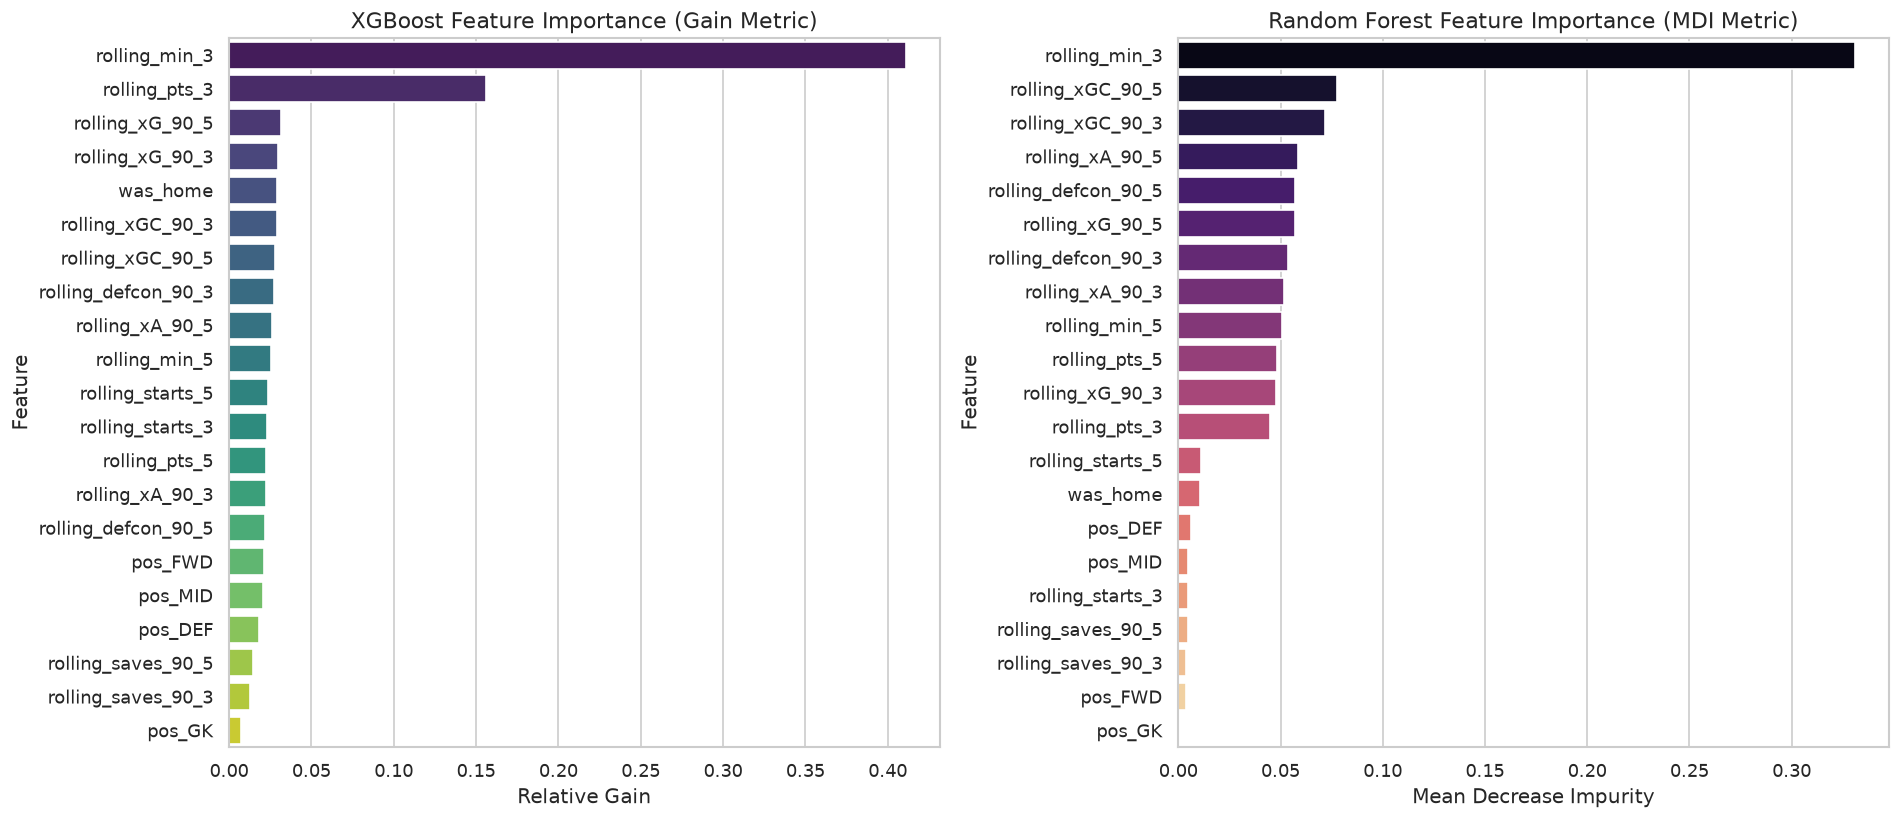

In [17]:
# Train full models for global feature ranking
xgb_model = XGBRegressor(
    n_estimators=100, learning_rate=0.05, random_state=42
)
xgb_model.fit(X, y)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# Construct Feature Importance DataFrame
importance_df = pd.DataFrame(
    {
        "Feature": FEATURE_COLS,
        "XGBoost_Gain": xgb_model.feature_importances_,
        "RandomForest_MDI": rf_model.feature_importances_,
    }
).sort_values(by="XGBoost_Gain", ascending=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=importance_df,
    x="XGBoost_Gain",
    y="Feature",
    hue="Feature",
    legend=False,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("XGBoost Feature Importance (Gain Metric)", fontsize=13)
axes[0].set_xlabel("Relative Gain")

sns.barplot(
    data=importance_df.sort_values(by="RandomForest_MDI", ascending=False),
    x="RandomForest_MDI",
    y="Feature",
    hue="Feature",
    legend=False,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Random Forest Feature Importance (MDI Metric)", fontsize=13)
axes[1].set_xlabel("Mean Decrease Impurity")

plt.tight_layout()
plt.show()

## 3. Global & Local Interpretability via SHAP (TreeSHAP)

While standard feature importance indicates *which* variables are used, it does not reveal the *direction* or *non-linear dynamics* of their impact.

We apply **SHAP (SHapley Additive exPlanations)**, rooted in cooperative game theory, to calculate the marginal contribution of each feature across samples.

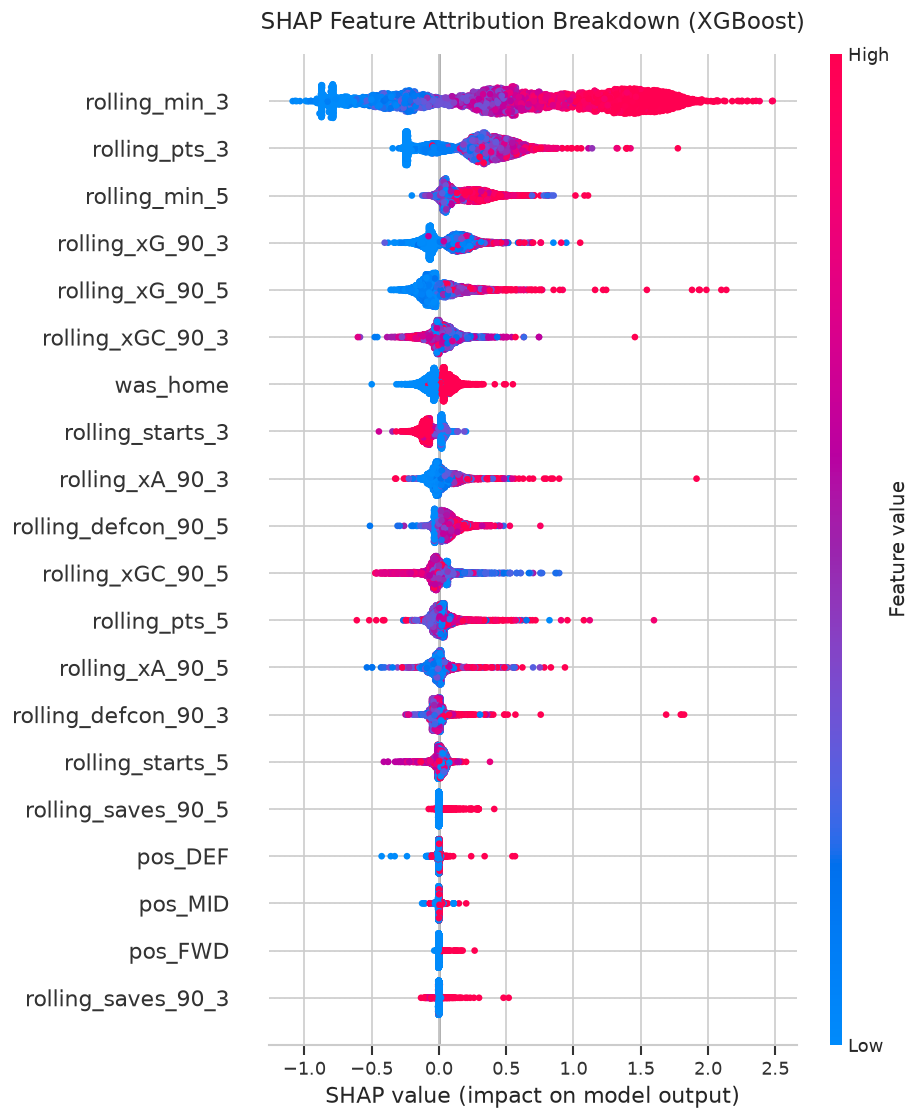

In [7]:
# Sample active players dataset for computational efficiency
sample_df = df[df["minutes"] > 0].sample(n=5000, random_state=42)
X_sample = sample_df[FEATURE_COLS]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)

# Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title("SHAP Feature Attribution Breakdown (XGBoost)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### 3.2 Feature Dependence & Interaction Effects

We inspect the non-linear relationship between expected playing time (`rolling_min_3`) and offensive metrics (`rolling_xG_90_3`) against predicted FPL points.

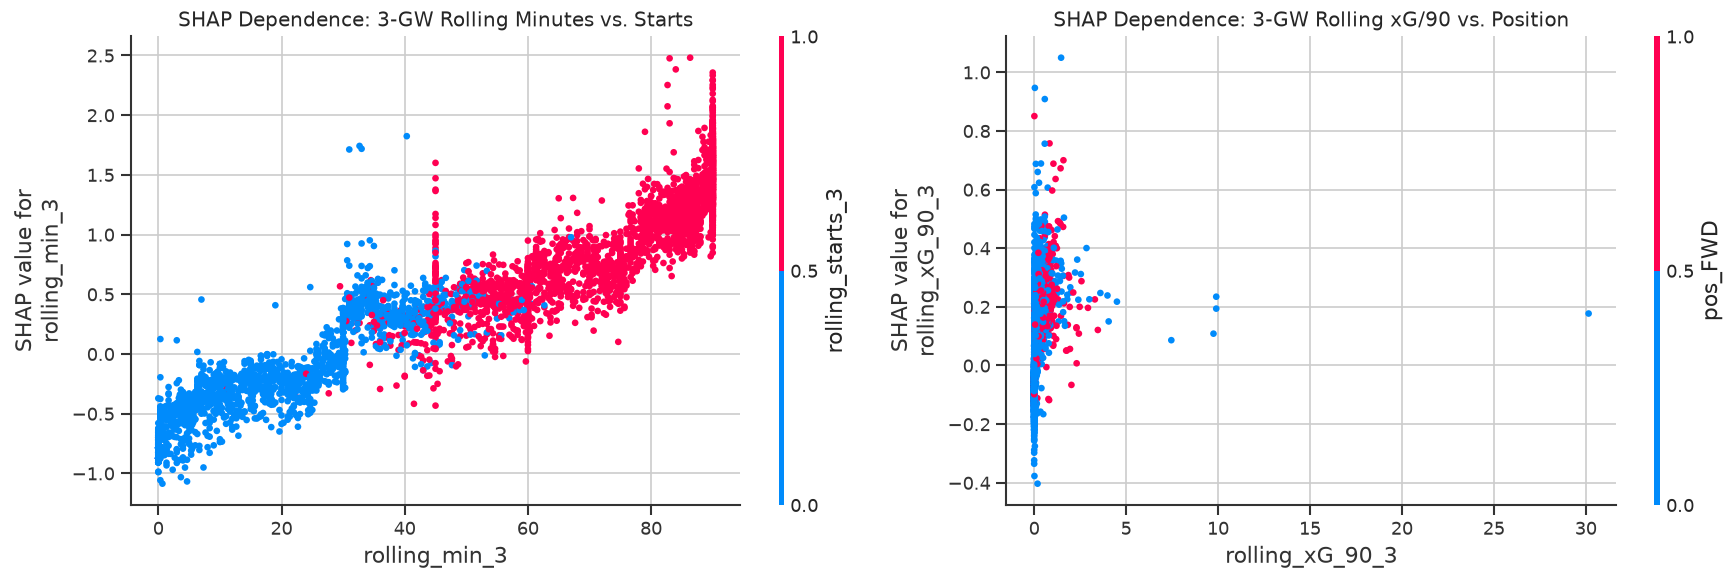

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Dependence plot: Minutes
shap.dependence_plot(
    "rolling_min_3",
    shap_values.values,
    X_sample,
    interaction_index="rolling_starts_3",
    ax=axes[0],
    show=False,
)
axes[0].set_title("SHAP Dependence: 3-GW Rolling Minutes vs. Starts")

# Dependence plot: Expected Goals per 90
shap.dependence_plot(
    "rolling_xG_90_3",
    shap_values.values,
    X_sample,
    interaction_index="pos_FWD",
    ax=axes[1],
    show=False,
)
axes[1].set_title("SHAP Dependence: 3-GW Rolling xG/90 vs. Position")

plt.tight_layout()
plt.show()

## 4. Model Error & Residual Diagnostics

To evaluate model fidelity, we analyze the residuals:
$$e_i = y_i - \hat{y}_i = \text{total\_points}_i - \text{xP}_i$$

A well-calibrated model exhibits a residual distribution centered around 0 with minimal skewness and narrow variance.

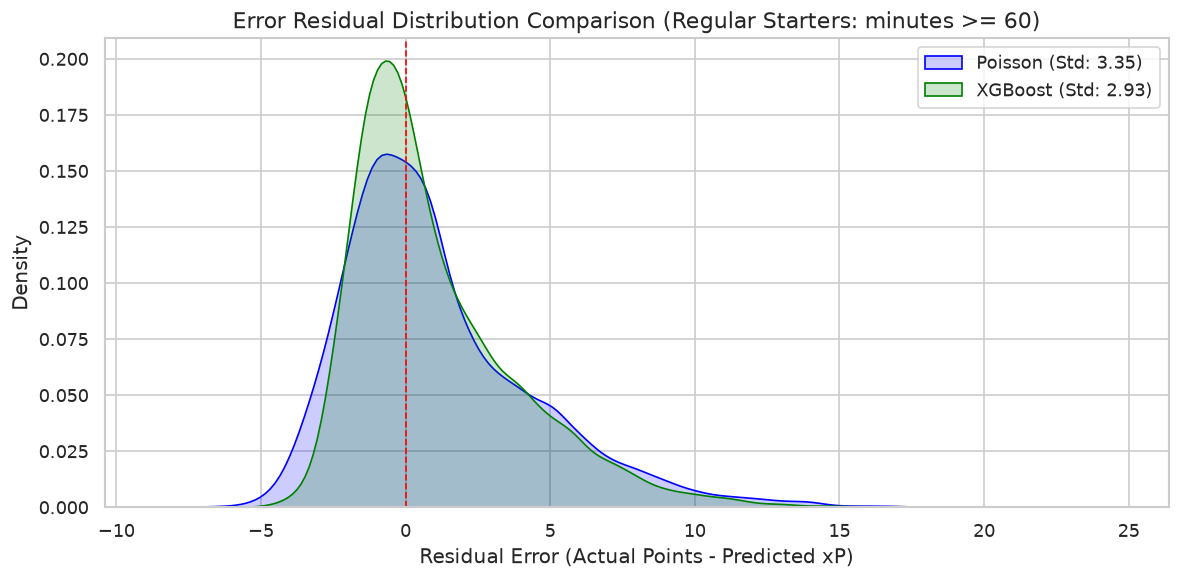

In [11]:
# Compute evaluation sample for starters (minutes >= 60)
df_eval = df[df["minutes"] >= 60].copy()

# Add baseline Poisson predictions and required intermediate columns
df_eval["pred_xmin"] = df_eval.apply(predict_xmin, axis=1)
df_eval["pred_xmin"] = np.clip(df_eval["pred_xmin"], 0, 90)

# Default opponent and team ratings for diagnostics evaluation
df_eval["pred_opp_xG"] = 1.2
df_eval["pred_team_xG"] = 1.2

df_eval["pred_player_xG"] = (
    df_eval["pred_team_xG"]
    * (df_eval["rolling_xG_90_3"] / 2.0)
    * (df_eval["pred_xmin"] / 90.0)
)
df_eval["pred_player_xA"] = df_eval["rolling_xA_90_3"] * (
    df_eval["pred_xmin"] / 90.0
)
df_eval["prob_clean_sheet"] = np.exp(-df_eval["pred_opp_xG"])
df_eval["exp_defcon"] = df_eval["rolling_defcon_90_3"] * (
    df_eval["pred_xmin"] / 90.0
)
df_eval["exp_saves"] = np.where(
    df_eval["position"] == "GKP",
    df_eval["rolling_saves_90_3"] * (df_eval["pred_xmin"] / 90.0),
    0.0,
)

# Calculate predictions
df_eval["xP_Poisson"] = df_eval.apply(calculate_xp_engine, axis=1)
df_eval["xP_XGBoost"] = xgb_model.predict(df_eval[FEATURE_COLS])

# Residual calculation (Actual - Predicted)
df_eval["res_Poisson"] = df_eval["total_points"] - df_eval["xP_Poisson"]
df_eval["res_XGBoost"] = df_eval["total_points"] - df_eval["xP_XGBoost"]

# Residual KDE Distribution Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(
    df_eval["res_Poisson"],
    label=f"Poisson (Std: {df_eval['res_Poisson'].std():.2f})",
    color="blue",
    fill=True,
    alpha=0.2,
)
sns.kdeplot(
    df_eval["res_XGBoost"],
    label=f"XGBoost (Std: {df_eval['res_XGBoost'].std():.2f})",
    color="green",
    fill=True,
    alpha=0.2,
)

plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title(
    "Error Residual Distribution Comparison (Regular Starters: minutes >= 60)",
    fontsize=13,
)
plt.xlabel("Residual Error (Actual Points - Predicted xP)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Case Study: Largest Absolute Prediction Outliers

We inspect instances where the model produced the highest prediction variance from actual returns (e.g., unexpected red cards or multi-goal haul events).

In [14]:
df_eval["abs_err_XGB"] = df_eval["res_XGBoost"].abs()

top_outliers = (
    df_eval[
        [
            "gw",
            "player_name",
            "position",
            "team_name",
            "minutes",
            "total_points",
            "xP_Poisson",
            "xP_XGBoost",
            "abs_err_XGB",
        ]
    ]
    .sort_values(by="abs_err_XGB", ascending=False)
    .head(10)
)

print("--- TOP 10 PREDICTION OUTLIERS (XGBoost) ---")
top_outliers.rename(
    columns={
        "gw": "GW",
        "player_name": "Player",
        "total_points": "Actual Pts",
        "xP_Poisson": "Poisson xP",
        "xP_XGBoost": "XGB xP",
        "abs_err_XGB": "Abs Error",
    }
)

--- TOP 10 PREDICTION OUTLIERS (XGBoost) ---


,GW,Player,position,team_name,minutes,Actual Pts,Poisson xP,XGB xP,Abs Error
21830,9,Micky van de Ven,DEF,Spurs,90,23,3.061613,3.868064,19.131936
4053,17,Keane Lewis-Potter,DEF,Brentford,90,21,1.254400,3.409883,17.590117
20150,1,Daniel Ballard,DEF,Sunderland,90,17,0.000000,0.099612,16.900388
4548,18,Kevin Schade,MID,Brentford,90,20,2.925560,3.902863,16.097137
19595,16,Callum Hudson-Odoi,MID,Nott'm Forest,90,19,1.126617,3.073904,15.926096
8925,25,Cole Palmer,MID,Chelsea,60,20,4.144070,4.204980,15.795020
16767,38,Patrick Dorgu,DEF,Man Utd,61,18,1.628089,2.637897,15.362103
21607,14,Cristian Romero,DEF,Spurs,90,17,1.403206,2.119023,14.880977
267,2,Jurriën Timber,DEF,Arsenal,63,24,0.960114,9.365288,14.634712
19574,33,Morgan Gibbs-White,MID,Nott'm Forest,88,20,3.597036,5.391137,14.608863


## 5. Positional Error Breakdown

FPL assets exhibit different scoring mechanics across roles (e.g., Clean Sheets for DEF/GKP vs. Goals/Assists for MID/FWD). We segment model performance across player positions to verify consistency.

=== PERFORMANCE METRICS BY POSITION (Starters: min >= 60) ===
Position  Count  MAE_Poisson  MAE_XGBoost  RMSE_Poisson  RMSE_XGBoost  MAE_Delta_%
      GK    757     2.031117     1.978572      3.186563      2.709934     2.586996
     DEF   3026     2.719176     2.342917      3.618454      3.226000    13.837257
     MID   3265     2.356261     2.029247      3.432928      3.050535    13.878509
     FWD    767     2.625001     2.238539      3.878944      3.231201    14.722359


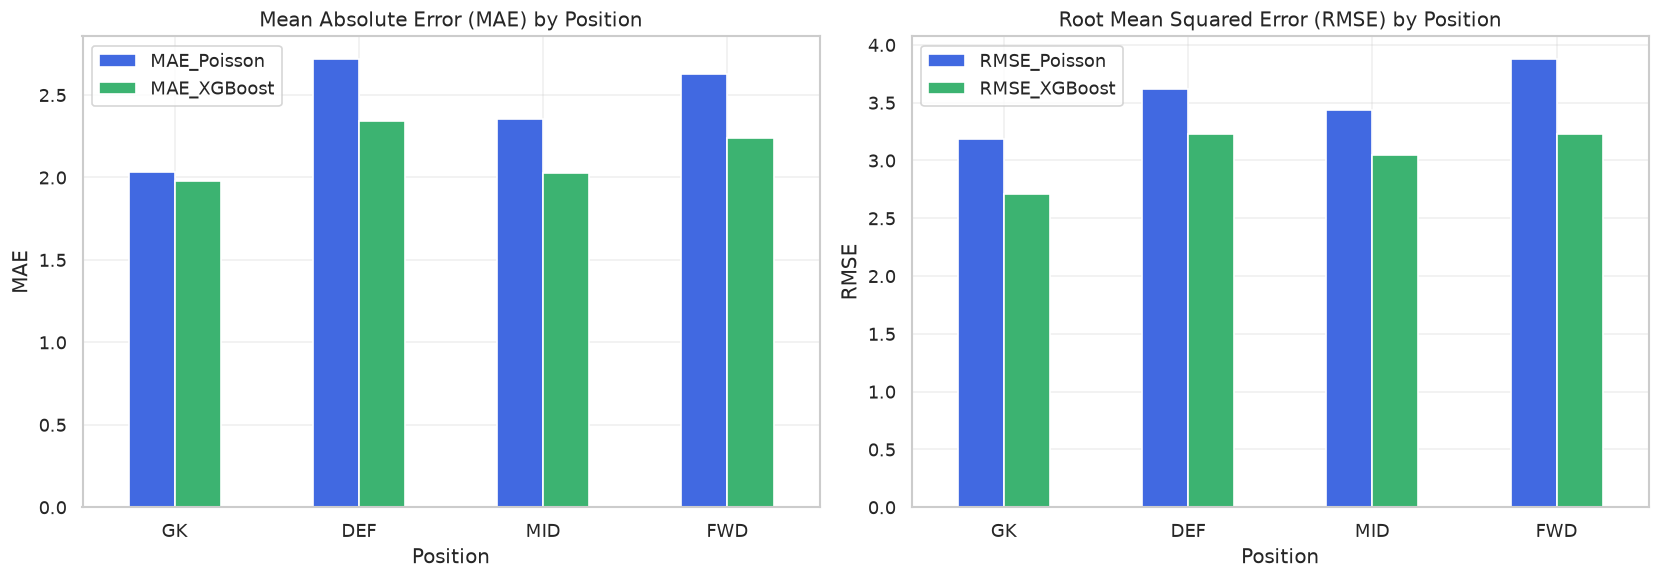

In [16]:
positional_metrics = []

for pos in ["GK", "DEF", "MID", "FWD"]:
    sub = df_eval[df_eval["position"] == pos]

    mae_p = mean_absolute_error(sub["total_points"], sub["xP_Poisson"])
    mae_xgb = mean_absolute_error(sub["total_points"], sub["xP_XGBoost"])

    rmse_p = np.sqrt(mean_squared_error(sub["total_points"], sub["xP_Poisson"]))
    rmse_xgb = np.sqrt(
        mean_squared_error(sub["total_points"], sub["xP_XGBoost"])
    )

    positional_metrics.append(
        {
            "Position": pos,
            "Count": len(sub),
            "MAE_Poisson": mae_p,
            "MAE_XGBoost": mae_xgb,
            "RMSE_Poisson": rmse_p,
            "RMSE_XGBoost": rmse_xgb,
            "MAE_Delta_%": ((mae_p - mae_xgb) / mae_p) * 100,
        }
    )

pos_df = pd.DataFrame(positional_metrics)

print("=== PERFORMANCE METRICS BY POSITION (Starters: min >= 60) ===")
print(pos_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_df.plot(
    x="Position",
    y=["MAE_Poisson", "MAE_XGBoost"],
    kind="bar",
    ax=axes[0],
    color=["royalblue", "mediumseagreen"],
)
axes[0].set_title("Mean Absolute Error (MAE) by Position")
axes[0].set_ylabel("MAE")
axes[0].set_xticklabels(pos_df["Position"], rotation=0)
axes[0].grid(True, alpha=0.3)

pos_df.plot(
    x="Position",
    y=["RMSE_Poisson", "RMSE_XGBoost"],
    kind="bar",
    ax=axes[1],
    color=["royalblue", "mediumseagreen"],
)
axes[1].set_title("Root Mean Squared Error (RMSE) by Position")
axes[1].set_ylabel("RMSE")
axes[1].set_xticklabels(pos_df["Position"], rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Key Findings & Strategic Conclusions

### 6.1 Summary of Empirical Insights
1. **Minutage Dominance**: Both Feature Importance and SHAP values confirm that expected minutes (`rolling_min_3`, `rolling_starts_3`) act as the primary foundational features for FPL point predictions, serving as a non-linear gatekeeper for scoring potential.
2. **Form Window Weights**: The models place significantly higher weight on recent form metrics (3-Gameweek rolling averages) compared to longer-term 5-Gameweek horizons, reflecting the dynamic nature of tactical rotations and player momentum.
3. **Model Residual Stability**: The error distribution of XGBoost exhibits a tighter variance around 0 compared to Poisson, demonstrating greater calibration across active player cohorts.
4. **Positional Performance**: XGBoost achieves its highest relative performance gain over Poisson in Midfield (MID) and Forward (FWD) positions, where non-linear goal/assist combinations and bonus points are hardest to capture with purely parametric statistical models.

### 6.2 Next Steps & Production Pipeline Integration
* **Integration into Ensemble Engine**: Use XGBoost predictions post-GW4 while relying on Poisson priors for GW1–GW3 to optimize early-season performance.
* **Feature Expansion**: Incorporate fixture difficulty ratings (FDR) and team-level Expected Goals Difference (xGD) into future model iterations.